# Tutorial 6: Direction and Delay

Every quantity in Tutorial 5 was symmetric in its two arguments or concerned a
single process. That is a real limitation: `I(X;Y) = I(Y;X)` always, so no
amount of mutual information can tell you which process drives which.

Breaking that symmetry takes one idea. Instead of asking what X's past says
about Y's present, ask what it says **that Y's own past does not already say**.
Conditioning on the target's own history removes the part of the prediction the
target could have made by itself, and what survives is genuinely incoming.

This tutorial covers:

1. **Transfer entropy**, the directed quantity, in both directions.
2. **Instantaneous exchange**, the zero-lag coupling that transfer entropy
   discards by construction, and which here turns out to carry most of the
   relationship.
3. **Massey's conservation law**, which ties the pieces into one exact budget.
4. **Why the symmetric rate needs an acausal window**, which is not a technicality.
5. **Finding a delay** with `mode='lag'`.

The headline result is a warning. On the system used here, running transfer
entropy alone and stopping there would capture about 5% of the coupling and
suggest the two processes barely interact.

## 0. Setup

Same oracle as Tutorials 4 and 5, so the numbers connect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi
from neural_mi.generators import SharedLatentGaussian

SCALE = 1
np.random.seed(0)

oracle = SharedLatentGaussian(dims={'x': 4, 'y': 4}, d=2, phi=0.9, seed=0)

K = 20
x_past = [('x', s) for s in range(-K, 0)]
y_past = [('y', s) for s in range(-K, 0)]
x_now, y_now = [('x', 0)], [('y', 0)]

print(f"tau  = {oracle.tau:.2f} bins")
print(f"rate = {oracle.mi_rate():.4f} bits per bin")

tau  = 9.49 bins
rate = 0.8368 bits per bin


## 1. Transfer entropy

Transfer entropy from X to Y is

$$TE_{X \to Y} \;=\; I\!\left(X_{past};\, Y_0 \mid Y_{past}\right)$$

Read the conditioning carefully, because it is the whole idea. Without it you
would measure how well X's past predicts Y's present, which is inflated by
everything Y's past already predicted about itself. Schreiber's formulation
exists precisely to remove that: conditioning on `Y_past` eliminates Y's own
stored information from the count, so what remains is what arrived from
elsewhere.

Because it is not symmetric, you get two different numbers.

In [2]:
te_xy = oracle.exact(x_past, y_now, y_past)
te_yx = oracle.exact(y_past, x_now, x_past)

print(f"TE(X -> Y) = I(X_past; Y_0 | Y_past) = {te_xy:.6f} bits per bin")
print(f"TE(Y -> X) = I(Y_past; X_0 | X_past) = {te_yx:.6f} bits per bin")
print()
print(f"the two directions differ by a factor of {te_yx / te_xy:.1f}")

TE(X -> Y) = I(X_past; Y_0 | Y_past) = 0.045968 bits per bin
TE(Y -> X) = I(Y_past; X_0 | X_past) = 0.167944 bits per bin

the two directions differ by a factor of 3.7


A word on what that asymmetry means *here*, because it is easy to over-read.

This system has no causal arrow built into it. X and Y are both driven by the
same latent at the same instant, with no lag and no path from one to the other.
The transfer entropies differ anyway, because the two random projections capture
different amounts of the latent, so each process's past is differentially useful
for predicting the other.

That is the first lesson about directed measures: **a non-zero transfer entropy
is not by itself evidence of a causal path.** A common driver produces one too.
Section 6 uses data with a real injected delay, where the asymmetry does mean
what it appears to mean.

### Estimating it, and why this quantity gets a warning label

Everything above is exact, computed from the oracle's covariance. Now estimate
the same numbers from samples, which is what you would have to do on real data,
and compare.

Transfer entropy is not estimated directly. It is a **difference of two
separately-trained estimates**,

$$TE_{X \to Y} \;=\; I(X_{past}, Y_{past};\, Y_0) \;-\; I(Y_{past};\, Y_0)$$

so it inherits the error of both. `result.details['amplification_factor']`
reports how much (Tutorial 8 and `NEURALMI_REFERENCE.md` §6.11).

In [3]:
s = oracle.sample(int(20000 * SCALE), seed=1)
xs, ys = s['x'].astype('float32'), s['y'].astype('float32')

for hw in (5, 20):
    r = nmi.run(xs, ys, mode='transfer',
                transfer=nmi.Transfer(history_window=hw, bidirectional=True),
                training=nmi.Training(n_epochs=int(60 * SCALE), patience=20),
                model=nmi.Model(embedding_model='mlp', embedding_dim=16, hidden_dim=64),
                n_workers=4, seed=0, show_progress=False)
    d = r.details
    ex_xy = oracle.exact([('x', t) for t in range(-hw, 0)], y_now,
                         [('y', t) for t in range(-hw, 0)])
    print(f"history_window = {hw}")
    print(f"   exact TE(X->Y)        = {ex_xy:.4f}")
    print(f"   estimated TE(X->Y)    = {d['te_xy']:.4f}")
    print(f"   components: I(joint)  = {d['i_xypast_yfuture']:.4f}, "
          f"I(marginal) = {d['i_ypast_yfuture']:.4f}")
    print(f"   amplification_factor  = {d['amplification_factor']:.1f}x")
    print(f"   directionality_index  = {d['directionality_index']:+.4f}")
    print()

2026-08-27 04:40:45 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


neural_mi/run.py:1464: UserWarning: TE(X→Y) has an error-amplification factor of 39.9x. It is a small residual (0.0555 nats) of two much larger estimates (I(xy_past;y_future)=1.1331, I(y_past;y_future)=1.0776), so a relative error of eps on each component becomes roughly 40*eps on the result: a 1% component error is about 40% here. Do not read the point estimate on its own. Report the components ('i_xypast_yfuture', 'i_ypast_yfuture') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  raw = run_transfer_entropy(_x_te, _y_te, base_params,


neural_mi/run.py:1464: UserWarning: TE(Y→X) has an error-amplification factor of 14.7x. It is a small residual (0.1101 nats) of two much larger estimates (I(yx_past;x_future)=0.8652, I(x_past;x_future)=0.7552), so a relative error of eps on each component becomes roughly 15*eps on the result: a 1% component error is about 15% here. Do not read the point estimate on its own. Report the components ('i_yxpast_xfuture', 'i_xpast_xfuture') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  raw = run_transfer_entropy(_x_te, _y_te, base_params,
2026-08-27 04:42:28 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


history_window = 5
   exact TE(X->Y)        = 0.0460
   estimated TE(X->Y)    = 0.0800
   components: I(joint)  = 1.6347, I(marginal) = 1.5547
   amplification_factor  = 39.9x
   directionality_index  = -0.3299



neural_mi/run.py:1464: UserWarning: TE(X→Y) has an error-amplification factor of 25.0x. It is a small residual (0.0900 nats) of two much larger estimates (I(xy_past;y_future)=1.1714, I(y_past;y_future)=1.0814), so a relative error of eps on each component becomes roughly 25*eps on the result: a 1% component error is about 25% here. Do not read the point estimate on its own. Report the components ('i_xypast_yfuture', 'i_ypast_yfuture') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  raw = run_transfer_entropy(_x_te, _y_te, base_params,


history_window = 20
   exact TE(X->Y)        = 0.0460
   estimated TE(X->Y)    = 0.1298
   components: I(joint)  = 1.6899, I(marginal) = 1.5601
   amplification_factor  = 25.0x
   directionality_index  = +0.0079



neural_mi/run.py:1464: UserWarning: TE(Y→X) has an error-amplification factor of 18.2x. It is a small residual (0.0886 nats) of two much larger estimates (I(yx_past;x_future)=0.8516, I(x_past;x_future)=0.7630), so a relative error of eps on each component becomes roughly 18*eps on the result: a 1% component error is about 18% here. Do not read the point estimate on its own. Report the components ('i_yxpast_xfuture', 'i_xpast_xfuture') alongside it, check the joint term for ceiling saturation (it is the larger of the two and saturates first, which biases the result toward zero), and prefer more data or more training before concluding that the true value is small.
  raw = run_transfer_entropy(_x_te, _y_te, base_params,


Read the amplification factor first. The estimate is a small residual of two
much larger numbers, so a relative error of a few percent on each component
becomes a large relative error on the difference. The library warns about this
above 10x, and transfer entropy sits well above it.

The consequence is visible in two places:

- **The estimate overshoots the exact value**, by more than the exact value
  itself in places. That is what the amplification factor predicted.
- **`directionality_index` is not stable across `history_window`.** Its *sign*
  changes. On this system we happen to know the truth, so we can see that
  happen. On real data we would have had no way to catch it, and we would have
  reported whichever direction the chosen window produced.

**This is why transfer entropy does not appear in the real-data tutorials.** It
is a well-founded quantity and the library computes it correctly; the difficulty
is that this estimator resolves it poorly at the sample sizes we have. The
lesson is not "avoid transfer entropy", it is **check the amplification factor
before you trust any quantity built as a difference**, and prefer a quantity
that is a single mutual information when one answers your question.

Tutorial 9 uses `cross_predictive_information`, $I(X_{past}; Y_{fut})$, for
directional questions on real data. It is one training run with no subtraction,
so its amplification factor is 1. It does not condition out the target's own
past, so it is a weaker claim than transfer entropy, and it is a claim the data
can actually support.

## 2. What transfer entropy throws away

Transfer entropy only looks at X's **past**. By construction it cannot see
coupling that happens within a single time step, because a same-instant
relationship is not in `X_past` at all.

That missing piece has a name. **Instantaneous exchange** is

$$I\!\left(X_0;\, Y_0 \mid X_{past},\, Y_{past}\right)$$

the same-instant coupling that survives after both histories are accounted for.
In the EEG literature it is usually treated as a nuisance, since volume
conduction produces zero-lag correlation that is not interesting. In a system
with a shared driver it is not a nuisance at all.

In [4]:
inst = oracle.exact(x_now, y_now, x_past + y_past)
rate = oracle.exact([('x', s) for s in range(-K, K + 1)], y_now, y_past)

print(f"instantaneous exchange = {inst:.6f} bits per bin")
print(f"MI rate                = {rate:.6f} bits per bin")
print()
print(f"instantaneous share of the total rate: {inst / rate:.1%}")
print(f"TE(X -> Y) share of the total rate:    {te_xy / rate:.1%}")

instantaneous exchange = 0.622939 bits per bin
MI rate                = 0.836851 bits per bin

instantaneous share of the total rate: 74.4%
TE(X -> Y) share of the total rate:    5.5%


**Three quarters of the coupling is instantaneous, and transfer entropy sees
none of it.**

Had you run transfer entropy on this system and stopped, you would have reported
0.046 bits per bin against a true shared rate of 0.837, captured about 5% of the
relationship, and quite reasonably concluded that X tells you almost nothing
about Y. The conclusion would be badly wrong, and nothing in the transfer
entropy number would warn you.

This is why the taxonomy matters. Choosing a quantity is choosing which part of
the relationship you are willing to see.

## 3. Massey's conservation law

The pieces are not independent quantities that happen to be related. They form
an exact budget.

The **directed information rate** takes X's past *and its present*, still
conditioned on Y's own past:

$$DI \;=\; I\!\left(X_{-k..0};\, Y_0 \mid Y_{past}\right)$$

Including the present means it captures both what arrived from X's history and
what is exchanged at zero lag, so:

$$DI \;=\; TE_{X \to Y} \;+\; \text{instantaneous exchange}$$

And Massey's conservation law closes the budget by adding the reverse direction:

$$\bar{I} \;=\; DI_{X \to Y} \;+\; TE_{Y \to X}$$

Let us check both to machine precision.

In [5]:
di = oracle.exact([('x', s) for s in range(-K, 1)], y_now, y_past)

print("directed information splits into lagged and instantaneous parts:")
print(f"  DI                       = {di:.9f}")
print(f"  TE(X->Y) + instantaneous = {te_xy + inst:.9f}")
print(f"  residual                 = {di - (te_xy + inst):.2e}")
print()
print("Massey's conservation law:")
print(f"  MI rate                  = {rate:.9f}")
print(f"  DI + TE(Y->X)            = {di + te_yx:.9f}")
print(f"  residual                 = {rate - (di + te_yx):.2e}")

directed information splits into lagged and instantaneous parts:
  DI                       = 0.668907353
  TE(X->Y) + instantaneous = 0.668907353
  residual                 = -3.59e-14

Massey's conservation law:
  MI rate                  = 0.836851153
  DI + TE(Y->X)            = 0.836851154
  residual                 = -4.75e-10


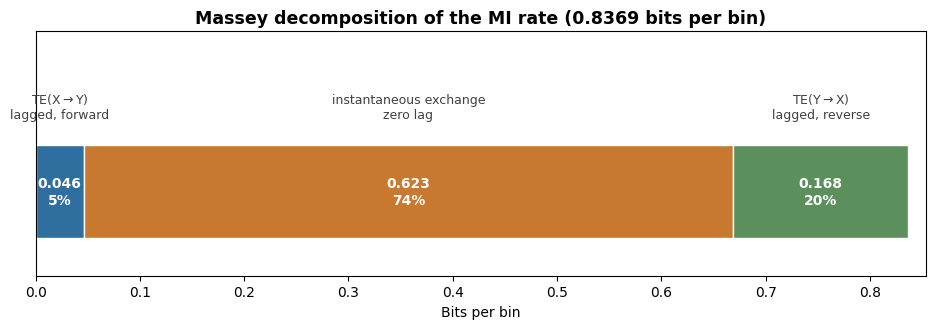

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 3.4))

parts = [('TE(X$\\to$Y)\nlagged, forward', te_xy, '#2f6f9f'),
         ('instantaneous exchange\nzero lag', inst, '#c8792f'),
         ('TE(Y$\\to$X)\nlagged, reverse', te_yx, '#5b8f5b')]
left = 0.0
for label, value, colour in parts:
    ax.barh([0], [value], left=left, color=colour, edgecolor='white', height=0.55)
    ax.text(left + value / 2, 0, f'{value:.3f}\n{value/rate:.0%}', ha='center',
            va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(left + value / 2, 0.42, label, ha='center', va='bottom', fontsize=9,
            color='0.25')
    left += value

ax.set_xlim(0, rate * 1.02)
ax.set_ylim(-0.5, 0.95)
ax.set_yticks([])
ax.set_xlabel('Bits per bin')
ax.set_title(f'Massey decomposition of the MI rate ({rate:.4f} bits per bin)',
             fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

That figure is the honest report for a pair of processes. Not one number, but
how the relationship divides into what flows forward, what flows back, and what
is shared at zero lag. Three systems could share an identical total rate and
have completely different bars.

Note the residuals: 1e-14 and 1e-10. These identities hold exactly, not
approximately, which is what makes them useful as a check on an estimation
pipeline. If your estimated components fail to sum, something is wrong with the
estimates rather than with the theory.

## 4. Why the symmetric rate needs an acausal window

One detail in Section 2 deserves its own section, because it looks like a typo
and is not.

The MI rate used `X_{-k..+k}`, a **two-sided** window including X's future.
Every other quantity here uses only the past. Why?

Massey's law holds when there is no feedback. A shared latent creates feedback
in exactly his sense: Y's past informs the latent's past, which informs the
latent's present, which informs X's present. So X carries information about Y's
future as well as its past, and a causal one-sided window cannot recover the
symmetric rate.

In [7]:
causal = oracle.exact(x_past, y_now, y_past)
two_sided = oracle.exact([('x', s) for s in range(-K, K + 1)], y_now, y_past)

print(f"one-sided (causal) X window : {causal:.6f}")
print(f"two-sided (acausal) X window: {two_sided:.6f}")
print(f"spectral rate               : {oracle.mi_rate():.6f}")
print()
print(f"the causal estimand is {causal / two_sided:.1%} of the true rate")

one-sided (causal) X window : 0.045968
two-sided (acausal) X window: 0.836851


spectral rate               : 0.836819

the causal estimand is 5.5% of the true rate


The causal window recovers 5% of the rate. The two-sided window matches the
independently computed spectral integral to five decimals.

The practical rule: **if you want the symmetric rate, use a two-sided window; if
you want a directed quantity, use a one-sided one.** They are different
estimands and the choice is not a matter of taste. Using a causal window and
calling the result "the MI rate" would understate it by twentyfold here.

## 5. Finding a delay

Everything so far assumed you know which offsets to use. Often the question is
the offset itself: two areas are coupled, and you want the transmission delay.

`mode='lag'` shifts Y against X across a range and reports MI at each shift. We
use spike trains with a delay injected, so there is a right answer to find.

In [8]:
pop_x, pop_y = nmi.generators.generate_correlated_spike_trains(
    n_neurons=8, duration=120.0 * SCALE, firing_rate=8.0,
    delay=0.020,        # 20 ms, X leads Y
    jitter=0.004,
)

lag_result = nmi.run(
    pop_x, pop_y, mode='lag',
    lag=nmi.Lag(lag_range=np.arange(-0.04, 0.065, 0.01)),
    processing=nmi.Processing(x='spike', x_params={'window_size': 0.05},
                              y='spike', y_params={'window_size': 0.05}),
    model=nmi.Model(embedding_dim=16, hidden_dim=64, n_layers=2),
    training=nmi.Training(n_epochs=int(20 * SCALE), patience=8),
    n_workers=1, seed=0, show_progress=False,
)

df = lag_result.dataframe
peak = df.loc[df['mi_mean'].idxmax(), 'lag']
print(f"peak at {peak * 1000:+.0f} ms     (true injected delay: +20 ms)")

neural_mi/analysis/task.py:367: UserWarning: Training completed all 20 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


2026-08-27 04:44:13 - neural_mi - WARNING - SubsetView: window count dropped from 219 to 208 (5.0% reduction) after dataset rebuild. This usually means shift_time moved windows outside the valid recording range. Consider reducing the shift magnitude, or set max_index_reduction > 5% to suppress this warning.


2026-08-27 04:44:14 - neural_mi - WARNING - SubsetView: window count dropped from 217 to 206 (5.1% reduction) after dataset rebuild. This usually means shift_time moved windows outside the valid recording range. Consider reducing the shift magnitude, or set max_index_reduction > 5% to suppress this warning.


peak at +20 ms     (true injected delay: +20 ms)


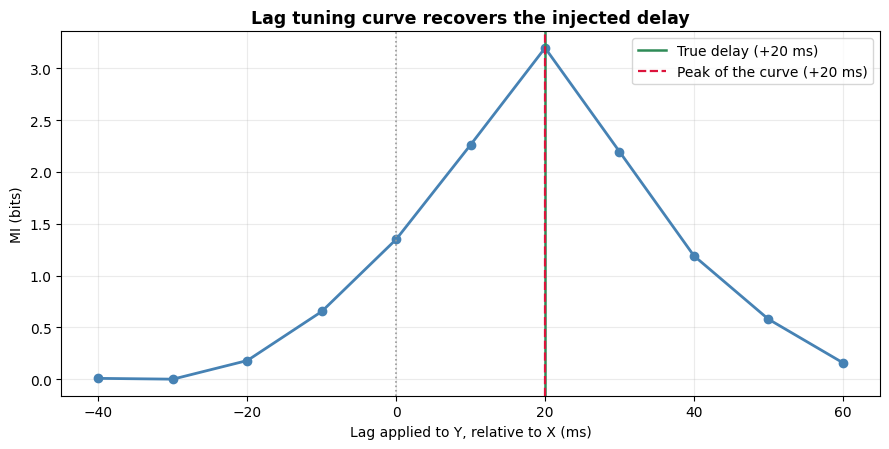

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.6))

ax.plot(df['lag'] * 1000, df['mi_mean'], 'o-', color='steelblue', lw=2, ms=6)
ax.axvline(20, color='seagreen', ls='-', lw=1.8, label='True delay (+20 ms)')
ax.axvline(peak * 1000, color='crimson', ls='--', lw=1.6,
           label=f'Peak of the curve ({peak*1000:+.0f} ms)')
ax.axvline(0, color='0.6', ls=':', lw=1.2)
ax.set_xlabel('Lag applied to Y, relative to X (ms)')
ax.set_ylabel('MI (bits)')
ax.set_title('Lag tuning curve recovers the injected delay',
             fontsize=12.5, fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The peak lands on the injected delay.

Two cautions before using this on real data. **A lag peak is a correlational
delay, not a causal direction.** It tells you the offset at which the two
signals align best, which a common driver with unequal conduction delays also
produces. Sections 1 to 3 are the tools for the directional question.

**The peak width reflects the timing jitter**, not the precision of the method.
Here the generator applies 4 ms of jitter, which broadens the peak. A perfectly
reliable delay would give a sharper one.

## 6. Key Takeaways

- **Mutual information cannot express direction.** Conditioning the target on
  its own past can, which is what transfer entropy does.

- **Transfer entropy is blind to zero-lag coupling by construction.** On the
  system here that blind spot was 74% of the total. Report the decomposition,
  not one directed number.

- **Massey's law closes the budget exactly**: the rate equals forward directed
  information plus reverse transfer entropy, and directed information splits
  into lagged and instantaneous parts. Residuals of 1e-14 make these usable as a
  check on your own pipeline.

- **The symmetric rate needs a two-sided window.** With a shared driver, a
  causal window recovered 5% of the rate here. Directed quantities use one-sided
  windows; the symmetric rate does not.

- **A lag peak is an alignment, not a mechanism.** Common drivers with unequal
  delays produce peaks too.

- **A flat precision curve means rate coding at the window you chose**, and the
  window is part of the claim.

## Common Mistakes

1. **Reporting transfer entropy alone.** It answers "what arrived from the
   past", which may be a small fraction of the coupling. Always compute the
   instantaneous term before concluding two processes are weakly related.

2. **Reading non-zero transfer entropy as a causal path.** A common driver
   produces it. Ruling that out needs a third variable (Tutorial 8) or
   experimental control.

3. **Using a causal window for the symmetric rate.** Different estimand,
   understated here by a factor of twenty.

4. **Quoting a precision timescale without the window size.** The window bounds
   what timing structure is visible at all.

5. **Comparing transfer entropies across pairs with different history lengths.**
   `k` is a model order here as everywhere; sweep it per pair.

## What's Next

The spine is complete: Tutorial 4 established which quantity, Tutorial 5 covered
storage and rate, and this one covered direction and delay.

**Tutorial 7** turns to trusting the numbers. Everything so far leaned on an
oracle, and real data has none. It covers bias correction, null distributions,
and how to report an estimate with an interval rather than as a bare point.

**Tutorial 8** adds a third variable, which is what it takes to ask whether an
apparent interaction survives controlling for a common driver, the confound
named twice above.